In [1]:
import numpy as np
#import gplately.pygplates as pygplates
import ptt
import gplately
import gplately.tools as tools
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io import shapereader as shpreader
import netCDF4
import warnings
from scipy import ndimage
import glob, os
from rasterio.features import rasterize
from rasterio.transform import from_bounds
import matplotlib.gridspec as gridspec
#from slabdip import SlabDipper
import matplotlib
import pandas as pd
from cmcrameri import cm
#import gplately.pygplates as pygplates
import glob, os
import matplotlib.pyplot as plt
from plate_model_manager import PlateModelManager

from gplately import pygplates

import geopandas as gpd

# matplotlib.rcParams['font.family'] = 'Arial'
# matplotlib.rcParams['pdf.fonttype'] = 42
# matplotlib.rcParams.update({
#     "pdf.use14corefonts": True
# })

reconstruction_times = np.arange(0,1800,1)
extent_global = [-180,180,-90,90]


##################################################################################################

            You are using a DEV version (1.3.0.post140+git.22c934e6) GPlately.     
            Some functionalities in the DEV version have not been tested thoroughly, 
            and may break your code or produce wrong results due to 
            its unstable nature(DEV in progress). Proceed With Caution!!!
            You might also need to install the DEV version plate_model_manager 
            from https://github.com/michaelchin/plate-model-manager.

            To disable this warning, set USING_DEV_VERSION to False in __init__.py or
            set DISABLE_GPLATELY_DEV_WARNING environment variable to true.

            `export DISABLE_GPLATELY_DEV_WARNING=true`
            
            If you prefer not seeing this warning always, you may set the environment variable 
            in your boot scripts, such as .bashrc, .profile, autoexec.bat, etc.
            
#################

In [2]:
use_local_files = True

if use_local_files:
    # Method 1: manually point to files
    input_directory = 'data/1.8Ga_model_optimised_mantle_ref_frame_20240725/1.8Ga_model_optimised_mantle_ref_frame_20240725'
    # Load rotation files
    rotation_filenames = glob.glob(os.path.join(input_directory, 'optimised_rotation_model_20240725_run3.rot'))
    rotation_model = pygplates.RotationModel(rotation_filenames)

    # Load static polygons
    static_polygons = pygplates.FeatureCollection(os.path.join(input_directory, 'static_polygons.gpmlz'))
    COBs = input_directory+'/COBfile_1800_0.gpml'
    # Load topology files and combine into a single FeatureCollection
    topology_filenames = [
        os.path.join(input_directory, '250-0_plate_boundaries.gpml'),
        os.path.join(input_directory, '410-250_plate_boundaries.gpml'),
        os.path.join(input_directory, '1800-1000_plate_boundaries.gpml'),
        os.path.join(input_directory, '1000-410_plate_boundaries.gpml'),
        os.path.join(input_directory, '1000-410-Convergence.gpml'),
        os.path.join(input_directory, '1000-410-Divergence.gpml'),
        #os.path.join(input_directory, '1000-410-Topologies.gpml'),
        os.path.join(input_directory, '1000-410-Transforms.gpml'),
        os.path.join(input_directory, 'TopologyBuildingBlocks.gpml'),
    ]
    
    # Create an empty list to hold all the features
    all_topology_features = []

    # Load each file and append its features to the list
    for topology_filename in topology_filenames:
        fc = pygplates.FeatureCollection(topology_filename)
        all_topology_features.extend(fc)

    # Create a single FeatureCollection from the combined features
    topology_features = pygplates.FeatureCollection(all_topology_features)

    # Optionally load other geological features if needed
    continents = pygplates.FeatureCollection(os.path.join(input_directory, 'shapes_continents.gpmlz'))
    COBs = pygplates.FeatureCollection(os.path.join(input_directory, 'COBfile_1800_0.gpml'))
    #Paleomagnetic_poles = pygplates.FeatureCollection(os.path.join(input_directory, 'Paleomagnetic_poles.gpml'))
    shapes_coasts = pygplates.FeatureCollection(os.path.join(input_directory, 'shapes_coasts.gpmlz'))
    #deposits = pygplates.FeatureCollection('/data/Craton_HS_2B_PLATEID1/Craton_Deposits_PLATEID1.gpml')

    # Create PlateReconstruction model
    model = gplately.PlateReconstruction(rotation_model=rotation_model, 
                                     topology_features=topology_features, 
                                     static_polygons=static_polygons)

    # Now you can proceed with your reconstruction and plotting...


C:\Users\Hojat\.conda\envs\gplately\lib\site-packages\gplately\pygplates.py:347: ImportWarning: 
FeatureCollection: No filename associated with <class 'list'> in __init__
 ensure pygplates is imported from gplately. Run,
 from gplately import pygplates


In [3]:
gplot = gplately.PlotTopologies(model,
                                    coastlines = shapes_coasts,
                                    continents =continents,
                                    COBs =COBs,
                                    time=1800
                                    #anchor_plate_id=0,
                                   )

In [4]:
reconstruction_time_map = 50

In [5]:
### Load craton database
Craton_HS_filename = "data/Craton_HS_2B_PLATEID1/Craton_HS_2B_Smoothed.shp"
Craton_HS_features = pygplates.FeatureCollection(Craton_HS_filename)
reconstructed_Craton_HS_features = model.reconstruct(Craton_HS_features, reconstruction_time_map)
#deposits = '/data/Craton_HS_2B_PLATEID1/Craton_Deposits_PLATEID1.gpml'

# Test

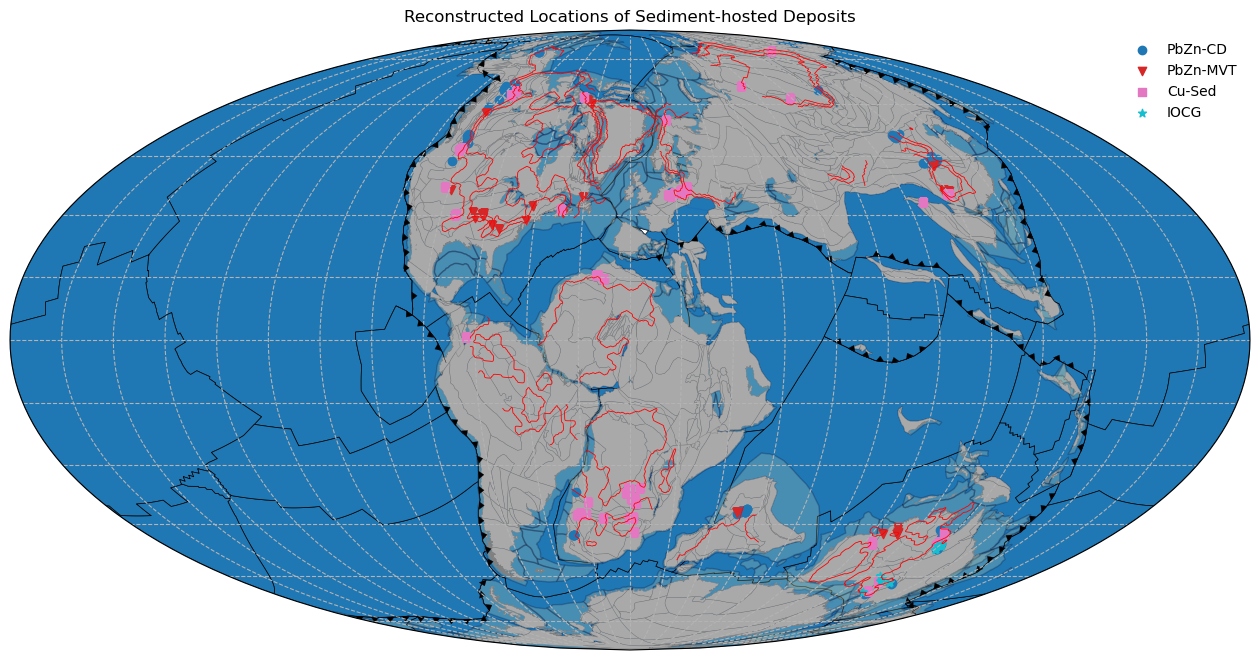

In [6]:
# Path to your shapefile
shapefile_path = 'data/Craton_HS_2B_PLATEID1/Craton_Deposits_PLATEID1.shp'

# Read the shapefile into a GeoDataFrame
gdf = gpd.read_file(shapefile_path)

# Dictionary to hold DataFrames for each type
metal_dict = dict()

# List of commodities (not used in the filtering, just for reference)
commodities = ['Cu (Mt)', 'Pb (Mt)', 'Zn (Mt)', 'Ni (Mt)']

# Get unique types from the 'Type' column
types = gdf['Type'].unique()

# Filter data by type
for type_name in types:
    df = gdf[gdf['Type'] == type_name]
    
    # Ensure that the 'Age' column is present and filter data
    if 'Age' in df.columns:
        df = df[df['Age'].notna()]
        df = df[df['Age'] > 0]  # Remove rows where Age = 0
        df = df[df['Age'] <= 1800]
        
        if df.shape[0] > 0:
            metal_dict[type_name] = df

# Initialize pygplates model (assuming you have the model defined)
# model = pygplates.PlateModel('path_to_your_plate_model')  # Update this with the path to your plate model

# Process each type
symbols = ['o', 'v', 's', '*', 'd', '^', 'P'] * 2
colors = plt.cm.tab10(np.linspace(0, 1, len(metal_dict)))

# Set the reconstruction time
reconstruction_time_map = 120

# Set up a GeoAxis plot
fig = plt.figure(figsize=(16, 12), dpi=100)
ax = fig.add_subplot(111, projection=ccrs.Mollweide(central_longitude=0))
ax.set_global()
ax.gridlines(color='0.7', linestyle='--', xlocs=np.arange(-180, 180, 15), ylocs=np.arange(-90, 90, 15))
ax.set_title("Reconstructed Locations of Sediment-hosted Deposits")

# Plot shapefile features and reconstructed craton features
gplot.time = reconstruction_time_map  # Ma
gplot.plot_all_topologies(ax, color='black', linewidth=0.5,  tessellate_degrees=0.1)
gplot.plot_continent_ocean_boundaries(ax, color='b', alpha=0.05,  tessellate_degrees=0.1)
gplot.plot_continents(ax, facecolor='palegoldenrod', alpha=0.2)
gplot.plot_coastlines(ax, facecolor='darkgray', edgecolor='grey', linewidth=0.3)
#gplot.plot_ridges_and_transforms(ax, color='gray')
gplot.plot_trenches(ax, color='k', linewidth=0.3,  tessellate_degrees=0.1)
gplot.plot_subduction_teeth(ax, color='k', linewidth=0.2)


# gplot.plot_continents(ax, facecolor='w')
# gplot.plot_coastlines(ax, facecolor='lightgrey', alpha=0.46)
# gplot.plot_trenches(ax, color='w', linewidth=4)
# gplot.plot_all_topological_sections(ax, color='silver', tessellate_degrees=1)
# gplot.plot_trenches(ax, label = "Trenches with polarity teeth")
# gplot.plot_subduction_teeth(ax, color='k', zorder=8)

# # Reconstruct Craton_HS
reconstructed_Craton_HS_features = model.reconstruct(Craton_HS_features, reconstruction_time_map)
gplot.plot_feature(ax, reconstructed_Craton_HS_features, color='red', linewidth=0.6)

# Initialize lists for legend handles and labels
handles = []
labels = []

# Iterate over each type in metal_dict
for i, (type_name, df) in enumerate(metal_dict.items()):
    # Ensure 'Lon_' and 'Lat_' columns are present
    if 'Lon_' in df.columns and 'Lat_' in df.columns and 'Age' in df.columns:
        lon = df['Lon_'].tolist()
        lat = df['Lat_'].tolist()
        age = df['Age'].tolist()

        # Create pygplates.Points from DataFrame
        gpts = gplately.Points(
            model,
            lon,
            lat,
            plate_id=df.get('PLATEID1', []).tolist()
        )

        try:
            rlons, rlats = gpts.reconstruct(reconstruction_time_map, return_array=True)
        except Exception as e:
            print(f"Error reconstructing points for {type_name}: {e}")
            continue

        # Filter by age
        mask_age = np.array(age) >= reconstruction_time_map
        if not np.any(mask_age):
            print(f"No data points to plot for {type_name} at this time")
            continue

        # Plot points with different color and symbol for each type
        color = colors[i % len(colors)]
        symbol = symbols[i % len(symbols)]
        scatter = ax.scatter(
            rlons[mask_age], 
            rlats[mask_age], 
            color=color, 
            marker=symbol, 
            transform=ccrs.PlateCarree(), 
            label=type_name
        )

        # Append scatter plot handle and label for legend
        handles.append(scatter)
        labels.append(type_name)

# Add legend with handles and labels
ax.legend(handles=handles, labels=labels, frameon=False)

plt.show()


# Make png files

KeyboardInterrupt: 

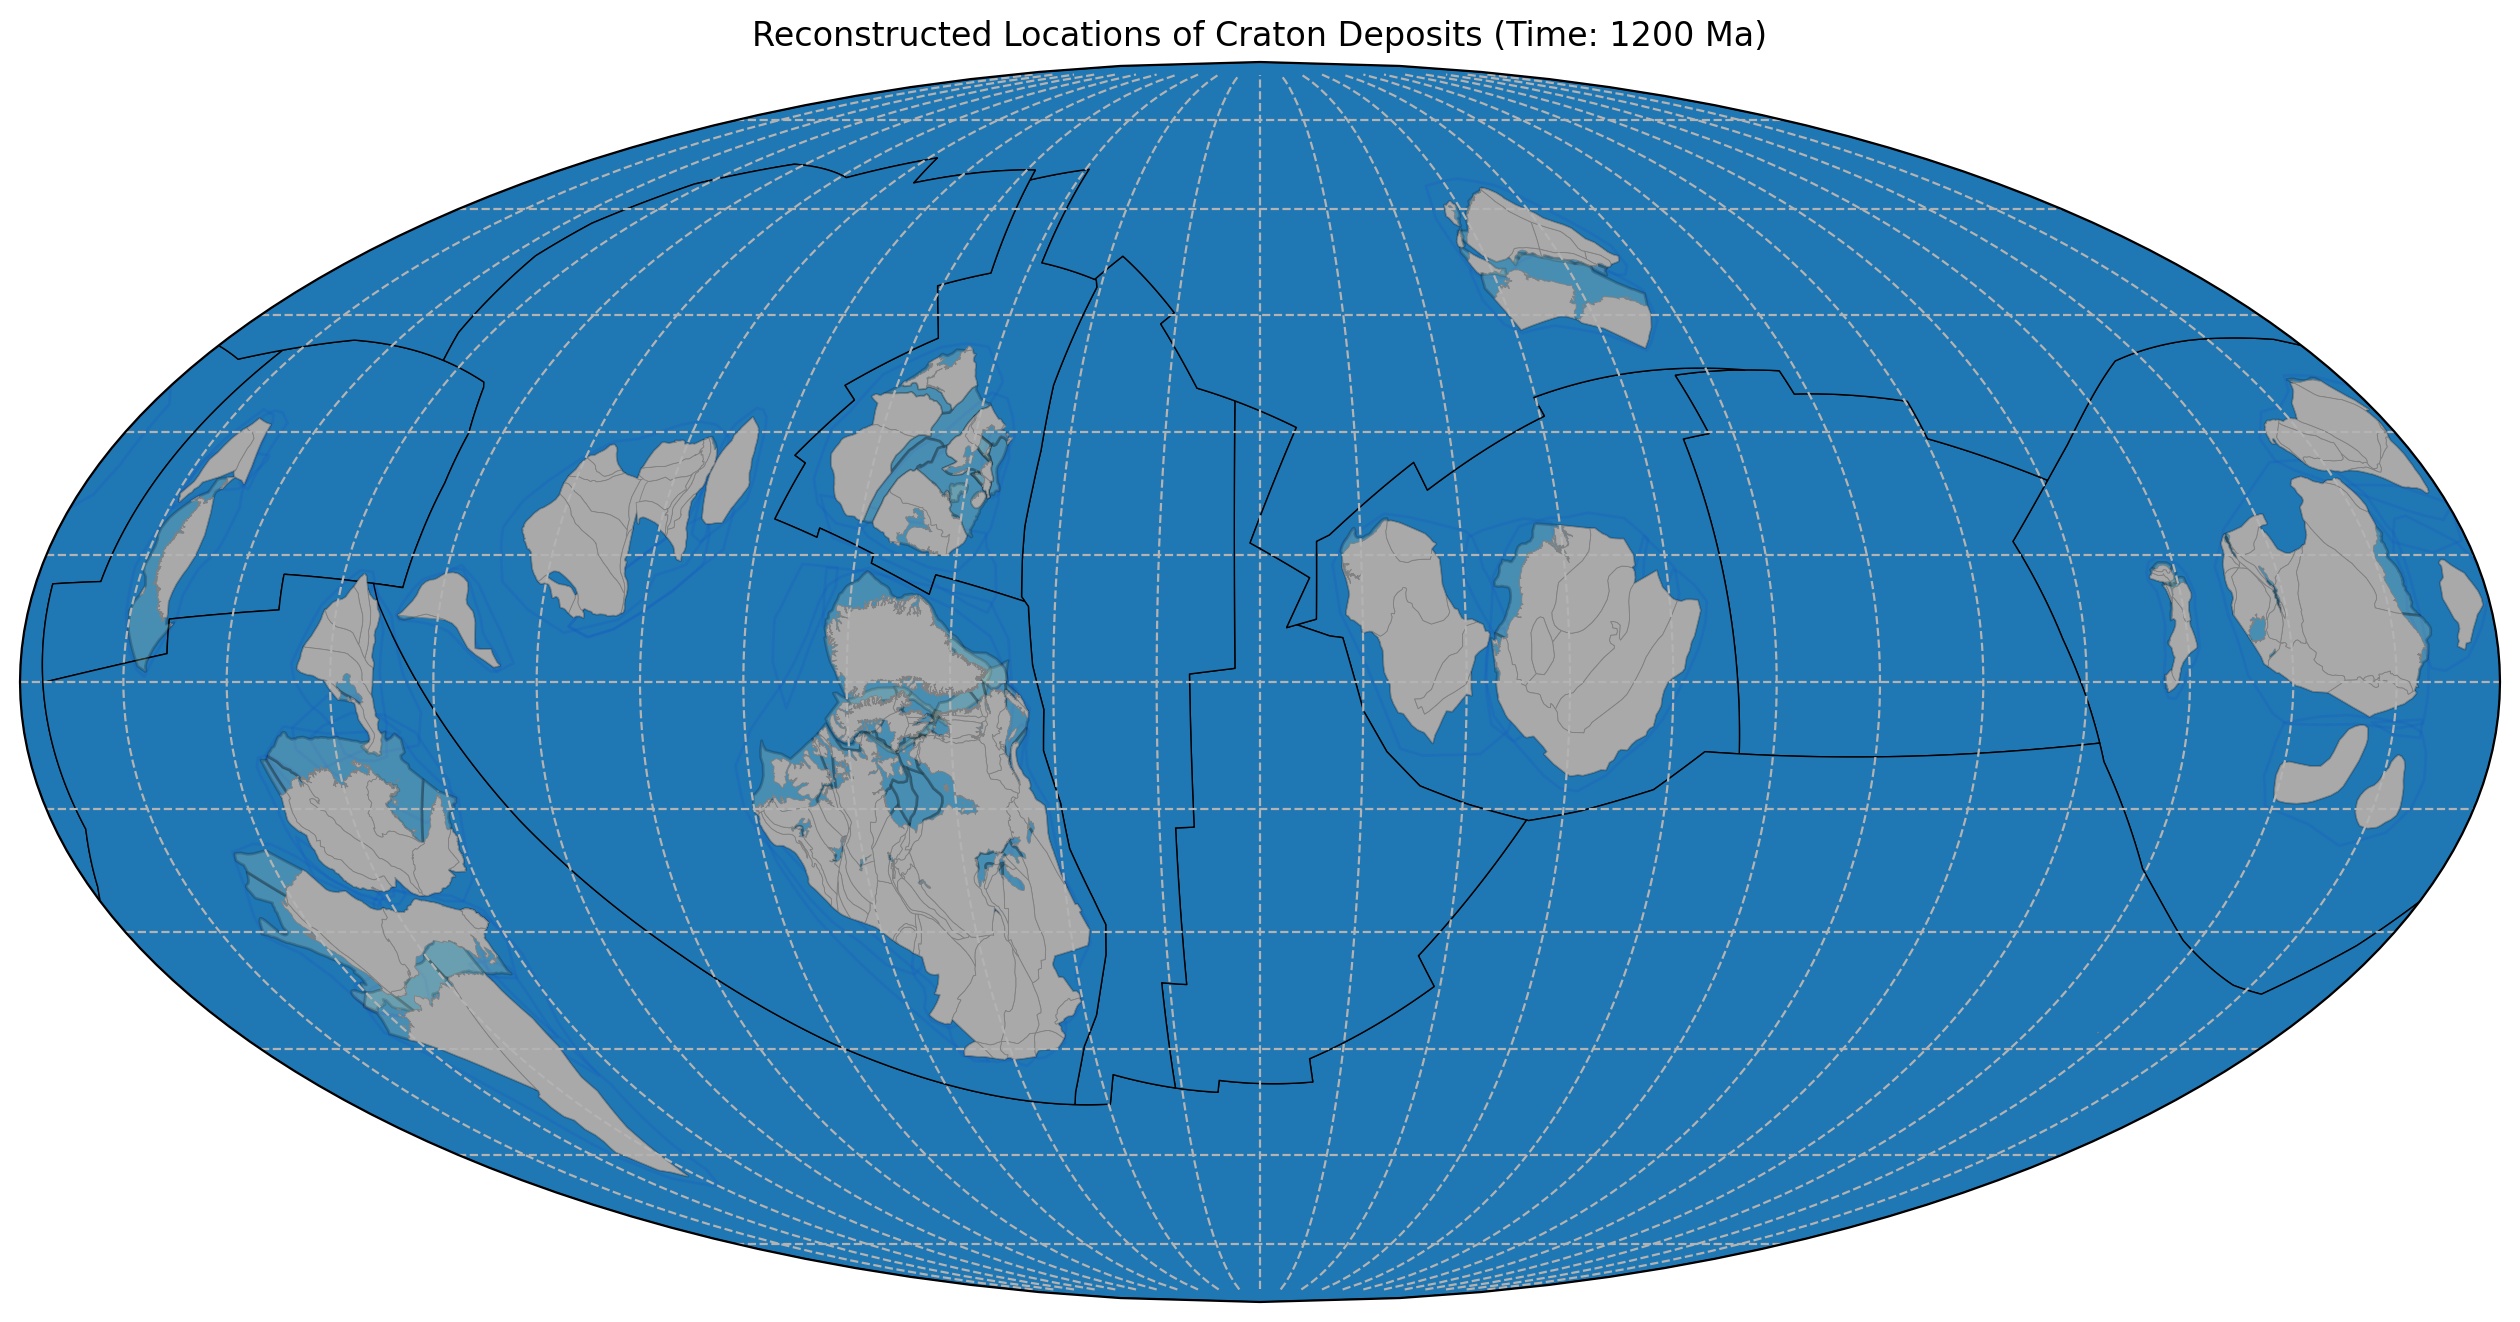

In [7]:

# Load craton database (Line)
Craton_HS_filename = "data/Craton_HS_2B_PLATEID1/Craton_HS_2B_Smoothed.shp"
Craton_HS_features = pygplates.FeatureCollection(Craton_HS_filename)

# Load Deposits (Point)
shapefile_path = 'data/Craton_HS_2B_PLATEID1/Craton_Deposits_PLATEID1.shp'
gdf = gpd.read_file(shapefile_path)

# Define size classes and corresponding symbol sizes based on TM2
size_classes = [(0, 4), (4, 12), (12, 28), (28, 52), (52, float('inf'))]
size_labels = ['< 4', '4-12', '12-28', '28-52', '> 52']
size_markers = [20, 50, 80, 110, 140]  # Symbol sizes for each class

# Function to get the marker size based on TM2 value
def get_size(tm2_value):
    for (low, high), size_marker in zip(size_classes, size_markers):
        if low <= tm2_value < high:
            return size_marker
    return size_markers[-1]  # Return largest size if out of range

# Dictionary to hold DataFrames for each type
metal_dict = dict()

# Get unique types from the 'Type' column
types = gdf['Type'].unique()

# Filter data by type
for type_name in types:
    df = gdf[gdf['Type'] == type_name]
    
    # Ensure that the 'Age' column is present and filter data
    if 'Age' in df.columns:
        df = df[df['Age'].notna()]
        df = df[df['Age'] > 0]  # Remove rows where Age = 0
        df = df[df['Age'] <= 1800]  # Replace with your maximum reconstruction time
        
        if df.shape[0] > 0:
            metal_dict[type_name] = df

# Initialize pygplates model (assuming you have the model defined)
# model = pygplates.PlateModel('path_to_your_plate_model')  # Update this with the path to your plate model

# Define the range of reconstruction times and interval
reconstruction_time_range = np.arange(1800, -1, -200)

# Define save folder for images
save_folder = 'Movie_Images_mantle_opt_2'
if not os.path.exists(save_folder):
    os.makedirs(save_folder)

# Define custom colors for each deposit type
custom_colors = ['blue', 'red', 'orange', 'purple']  # Adjust as needed
colors = custom_colors[:len(metal_dict)]

# Repeat colors if there are more deposits than colors
while len(colors) < len(metal_dict):
    colors += custom_colors[:len(metal_dict) - len(colors)]

def plot_and_save(reconstruction_time_map):
    fig = plt.figure(figsize=(16, 12), dpi=200)
    ax = fig.add_subplot(111, projection=ccrs.Mollweide(central_longitude=0))
    ax.set_global()
    ax.gridlines(color='0.7', linestyle='--', xlocs=np.arange(-180, 180, 15), ylocs=np.arange(-90, 90, 15))
    ax.set_title(f"Reconstructed Locations of Craton Deposits (Time: {reconstruction_time_map} Ma)")

    # Plot shapefile features and reconstructed craton features
    gplot.time = reconstruction_time_map  # Ma
    gplot.plot_all_topologies(ax, color='black', linewidth=0.5, tessellate_degrees=0.1)
    gplot.plot_continent_ocean_boundaries(ax, color='b', alpha=0.05, tessellate_degrees=0.1)
    gplot.plot_continents(ax, facecolor='palegoldenrod', alpha=0.2)
    gplot.plot_coastlines(ax, facecolor='darkgray', edgecolor='grey', linewidth=0.3)
    #gplot.plot_ridges_and_transforms(ax, color='gray', tessellate_degrees=0.1)
    gplot.plot_trenches(ax, color='k', linewidth=0.3, tessellate_degrees=0.1)
    gplot.plot_subduction_teeth(ax, color='k', linewidth=0.2)
    
    # Reconstruct Craton_HS
    reconstructed_Craton_HS_features = model.reconstruct(Craton_HS_features, reconstruction_time_map)
    gplot.plot_feature(ax, reconstructed_Craton_HS_features, color='saddlebrown', linewidth=0.8)

    # Initialize lists for legend handles
    size_legend_handles = []
    type_legend_handles = []

    # Plot all points with circles of varying sizes based on "TM2" values
    for i, (type_name, df) in enumerate(metal_dict.items()):
        lon = df['Lon_']
        lat = df['Lat_']
        tm2 = df['TM2']
        ids = df['Deposit']

        # Create pygplates.Points from DataFrame
        gpts = gplately.Points(
            model,
            lon,
            lat,
            plate_id=df.get('PLATEID1', []).tolist()
        )

        try:
            rlons, rlats = gpts.reconstruct(reconstruction_time_map, return_array=True)
        except Exception as e:
            print(f"Error reconstructing points for {type_name}: {e}")
            continue

        mask_age = df['Age'] >= reconstruction_time_map

        for (low, high), size_marker in zip(size_classes, size_markers):
            mask_size = (tm2 >= low) & (tm2 < high)
            mask = mask_age & mask_size
            scatter = ax.scatter(
                rlons[mask], 
                rlats[mask], 
                color=colors[i], 
                marker='o', 
                transform=ccrs.PlateCarree(), 
                s=size_marker,  # Set sizes based on TM2 values
                label=None, 
                edgecolor='black', 
                linewidth=0.5, 
                alpha=0.6
            )

            # Label points with "ID" where TM2 > 12, and avoid overlap
            for lon, lat, tm_value, deposit_id in zip(rlons[mask], rlats[mask], tm2[mask], ids[mask]):
                if tm_value > 20:
                    offset = 2  # Offset to avoid overlap
                    ax.text(
                        lon, 
                        lat + offset, 
                        deposit_id, 
                        transform=ccrs.PlateCarree(), 
                        fontsize=5, 
                        ha='center', 
                        va='bottom', 
                        color='black', 
                        bbox=dict(facecolor='white', edgecolor='none', alpha=0.4)
                    )

    # Add legend for circle sizes
    size_legend_handles = [plt.scatter([], [], marker='o', s=size_marker, label=label, color='gray', edgecolor='black', linewidth=0.5) for size_marker, label in zip(size_markers, size_labels)]
    
    # Add legend for deposit types (colors)
    type_legend_handles = [plt.Line2D([0], [0], marker='o', color='w', label=type_name, markersize=10, markerfacecolor=color, markeredgecolor='black', linewidth=0.5) for type_name, color in zip(metal_dict.keys(), colors)]
    
    # Combine legends
    all_handles = size_legend_handles + type_legend_handles
    all_labels = size_labels + list(metal_dict.keys())
    
    ax.legend(handles=all_handles, labels=all_labels, loc='upper right', title='Deposits Size (Mt), Types', frameon=False, bbox_to_anchor=(1.0, 1.16))

    # Save the plot as an image
    plt.savefig(os.path.join(save_folder, f'Reconstructed_Deposits_{reconstruction_time_map}.png'), bbox_inches='tight')
    plt.close(fig)

# Create plots and save them for each reconstruction_time_map value
for reconstruction_time_map in reconstruction_time_range:
    plot_and_save(reconstruction_time_map)


In [23]:

# Load craton database (Line)
Craton_HS_filename = "data/Craton_HS_2B_PLATEID1/Craton_HS_2B_Smoothed.shp"
Craton_HS_features = pygplates.FeatureCollection(Craton_HS_filename)

# Load Deposits (Point)
shapefile_path = 'data/Craton_HS_2B_PLATEID1/Craton_Deposits_PLATEID1.shp'
gdf = gpd.read_file(shapefile_path)

# Define size classes and corresponding symbol sizes based on TM2
size_classes = [(0, 4), (4, 12), (12, 28), (28, 52), (52, float('inf'))]
size_labels = ['< 4', '4-12', '12-28', '28-52', '> 52']
size_markers = [15, 40, 80, 110, 150]  # Symbol sizes for each class

# Function to get the marker size based on TM2 value
def get_size(tm2_value):
    for (low, high), size_marker in zip(size_classes, size_markers):
        if low <= tm2_value < high:
            return size_marker
    return size_markers[-1]  # Return largest size if out of range

# Dictionary to hold DataFrames for each type
metal_dict = dict()

# Get unique types from the 'Type' column
types = gdf['Type'].unique()

# Filter data by type
for type_name in types:
    df = gdf[gdf['Type'] == type_name]
    
    # Ensure that the 'Age' column is present and filter data
    if 'Age' in df.columns:
        df = df[df['Age'].notna()]
        df = df[df['Age'] > 0]  # Remove rows where Age = 0
        df = df[df['Age'] <= 1800]  # Replace with your maximum reconstruction time
        
        if df.shape[0] > 0:
            metal_dict[type_name] = df

# Initialize pygplates model (assuming you have the model defined)
# model = pygplates.PlateModel('path_to_your_plate_model')  # Update this with the path to your plate model

# Define the range of reconstruction times and interval
reconstruction_time_range = np.arange(1800, -1, -200)

# Define save folder for images
save_folder = 'Movie_Images_mantle_opt_2'
if not os.path.exists(save_folder):
    os.makedirs(save_folder)

# Define custom colors for each deposit type
custom_colors = ['green', 'red', 'gold', 'purple']  # Adjust as needed
colors = custom_colors[:len(metal_dict)]

# Repeat colors if there are more deposits than colors
while len(colors) < len(metal_dict):
    colors += custom_colors[:len(metal_dict) - len(colors)]

def plot_and_save(reconstruction_time_map):
    fig = plt.figure(figsize=(16, 12), dpi=200)
    ax = fig.add_subplot(111, projection=ccrs.Mollweide(central_longitude=0))
    ax.set_global()
    ax.gridlines(color='0.7', linestyle='--', xlocs=np.arange(-180, 180, 15), ylocs=np.arange(-90, 90, 15))
    
    # Set a generic title without the time
    ax.set_title("Reconstructed Locations of Craton Deposits")

    # ... [rest of the existing plotting code] ...

    # Add time information to a text box in the top left of the legend
    time_text = plt.text(
        0.02, 0.98,  # x, y coordinates in axes fraction
        f"Time: {reconstruction_time_map} Ma", 
        transform=ax.transAxes, 
        verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7),
        fontsize=10
    )

    # ... [rest of the existing code] ...

    # Plot shapefile features and reconstructed craton features
    gplot.time = reconstruction_time_map  # Ma
    gplot.plot_all_topologies(ax, color='black', linewidth=0.5, tessellate_degrees=0.1)
    gplot.plot_continent_ocean_boundaries(ax, color='b', alpha=0.05, tessellate_degrees=0.1)
    gplot.plot_continents(ax, facecolor='palegoldenrod', alpha=0.2)
    gplot.plot_coastlines(ax, facecolor='darkgray', edgecolor='grey', linewidth=0.3)
    #gplot.plot_ridges_and_transforms(ax, color='gray', tessellate_degrees=0.1)
    gplot.plot_trenches(ax, color='k', linewidth=0.3, tessellate_degrees=0.1)
    gplot.plot_subduction_teeth(ax, color='k', linewidth=0.2)
    
    # Reconstruct Craton_HS
    reconstructed_Craton_HS_features = model.reconstruct(Craton_HS_features, reconstruction_time_map)
    gplot.plot_feature(ax, reconstructed_Craton_HS_features, color='saddlebrown', linewidth=0.8)

    # Initialize lists for legend handles
    size_legend_handles = []
    type_legend_handles = []

    # Plot all points with circles of varying sizes based on "TM2" values
    for i, (type_name, df) in enumerate(metal_dict.items()):
        lon = df['Lon_']
        lat = df['Lat_']
        tm2 = df['TM2']
        ids = df['Deposit']

        # Create pygplates.Points from DataFrame
        gpts = gplately.Points(
            model,
            lon,
            lat,
            plate_id=df.get('PLATEID1', []).tolist()
        )

        try:
            rlons, rlats = gpts.reconstruct(reconstruction_time_map, return_array=True)
        except Exception as e:
            print(f"Error reconstructing points for {type_name}: {e}")
            continue

        mask_age = df['Age'] >= reconstruction_time_map

        for (low, high), size_marker in zip(size_classes, size_markers):
            mask_size = (tm2 >= low) & (tm2 < high)
            mask = mask_age & mask_size
            scatter = ax.scatter(
                rlons[mask], 
                rlats[mask], 
                color=colors[i], 
                marker='o', 
                transform=ccrs.PlateCarree(), 
                s=size_marker,  # Set sizes based on TM2 values
                label=None, 
                edgecolor='black', 
                linewidth=0.5, 
                alpha=0.6
            )

            # List of deposits to label
            deposits_to_label = [
                'Broken Hill', 'Olympic Dam', 'Kolwezi', 'Ngwako Pan', 
                'Lubin', 'Gorevsk', 'Viburnum Trend (distict)', 'Red Dog', 
                'Sullivan', 'Rampura-Agucha', 'Changba-Lijiagou'
            ]
            
            # Label points where deposit is in the list
            for lon, lat, deposit_id in zip(rlons[mask], rlats[mask], ids[mask]):
                if deposit_id in deposits_to_label:
                    offset = 2  # Offset to avoid overlap
                    ax.text(
                        lon, 
                        lat + offset, 
                        deposit_id, 
                        transform=ccrs.PlateCarree(), 
                        fontsize=10, 
                        ha='center', 
                        va='bottom', 
                        color='black', 
                        bbox=dict(facecolor='white', edgecolor='none', alpha=0.4)
                    )
        
    # Add legend for circle sizes (moved to right bottom)
    size_legend_handles = [plt.scatter([], [], marker='o', s=size_marker, label=label, color='gray', edgecolor='black', linewidth=0.5) for size_marker, label in zip(size_markers, size_labels)]
        
    # Add legend for deposit types (colors)
    type_legend_handles = [plt.Line2D([0], [0], marker='o', color='w', label=type_name, markersize=10, markerfacecolor=color, markeredgecolor='black', linewidth=0.5) for type_name, color in zip(metal_dict.keys(), colors)]
    
    # Add Craton Boundaries legend
    craton_legend_handle = plt.Line2D([0], [0], color='saddlebrown', linewidth=2, label='Craton Boundaries')
    
    # Deposit type legend at right top
    first_legend = ax.legend(handles=type_legend_handles, 
                             labels=list(metal_dict.keys()), 
                             loc='upper right', 
                             title='Deposit Types', 
                             frameon=True, 
                             bbox_to_anchor=(1.0, 1.01),
                             fancybox=True, 
                             shadow=True)
    
    # Add the first legend to the axes
    ax.add_artist(first_legend)
    
    # Deposit size legend at right bottom
    second_legend = ax.legend(handles=size_legend_handles, 
                              labels=size_labels, 
                              loc='lower right', 
                              title='Deposits Size (Mt)', 
                              frameon=True, 
                              bbox_to_anchor=(1.0, -0.08),
                              fancybox=True, 
                              shadow=True)
    
    # Add the second legend to the axes
    ax.add_artist(second_legend)
    
    # Craton Boundaries legend at bottom left
    third_legend = ax.legend(handles=[craton_legend_handle], 
                             loc='lower left', 
                             title='', 
                             frameon=True, 
                             bbox_to_anchor=(0.0, -0.08),
                             fancybox=True, 
                             shadow=True)

    # Save the plot as an image
    plt.savefig(os.path.join(save_folder, f'Reconstructed_Deposits_{reconstruction_time_map}.png'), bbox_inches='tight')
    plt.close(fig)

# Create plots and save them for each reconstruction_time_map value
for reconstruction_time_map in reconstruction_time_range:
    plot_and_save(reconstruction_time_map)


# Make Movie

In [25]:
import os
from PIL import Image
import moviepy.editor as mpy
import re

def numerical_sort(value):
    """ Helper function to sort filenames numerically. """
    numbers = re.findall(r'\d+', value)
    return int(numbers[-1]) if numbers else -1

def resize_images(image_paths, target_size):
    resized_images = []
    for image_path in image_paths:
        img = Image.open(image_path)
        img_resized = img.resize(target_size, Image.Resampling.LANCZOS)  # Updated to LANCZOS
        resized_image_path = image_path.replace('.png', '_resized.png')
        img_resized.save(resized_image_path)
        resized_images.append(resized_image_path)
    return resized_images

def create_movie_from_images(image_folder, output_movie_path, fps=5):
    # Get list of all PNG files in the folder
    image_files = [f for f in os.listdir(image_folder) if f.endswith('.png')]
    
    # Sort files numerically based on the number in the filename
    image_files.sort(key=numerical_sort)
    
    # Full paths to images
    image_paths = [os.path.join(image_folder, img) for img in image_files]
    
    # Get the size of the first image and resize all images to this size
    first_image = Image.open(image_paths[0])
    target_size = first_image.size
    
    # Resize all images to the target size
    resized_image_paths = resize_images(image_paths, target_size)
    
    # Create a video clip from the resized image sequence
    clip = mpy.ImageSequenceClip(resized_image_paths, fps=fps)
    
    # Write the video file
    clip.write_videofile(output_movie_path, fps=fps)
    
    # Optionally, delete resized images after movie creation
    for resized_image_path in resized_image_paths:
        os.remove(resized_image_path)



# Define the folder containing PNG images and the output movie file path
image_folder = './Movie_Images_mantle_opt_2'  # Replace with the actual folder path
output_movie_path = './Movie_Images_mantle_opt_2/Movie_Images_mantle_opt.mp4'  # Replace with desired output movie path

# Call the function to create the movie
create_movie_from_images(image_folder, output_movie_path)


Moviepy - Building video ./Movie_Images_mantle_opt_2/Movie_Images_mantle_opt.mp4.
Moviepy - Writing video ./Movie_Images_mantle_opt_2/Movie_Images_mantle_opt.mp4



Moviepy - Done !
Moviepy - video ready ./Movie_Images_mantle_opt_2/Movie_Images_mantle_opt.mp4
